<a href="https://colab.research.google.com/github/yogasriram2012-hub/high-altitude-anti-drone-SIH/blob/main/tracking/tracking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install filterpy --quiet

Running Day 4 simulation (v3): drone tracking with Kalman filter

Scenario: altitude=6000m, wind=20m/s, sensor noise std=20.5m
(Metrics below exclude the first 1s settling period)

Raw noisy measurement - mean error: 23.86m, max error: 68.46m
Kalman filtered track - mean error: 21.24m, max error: 55.64m


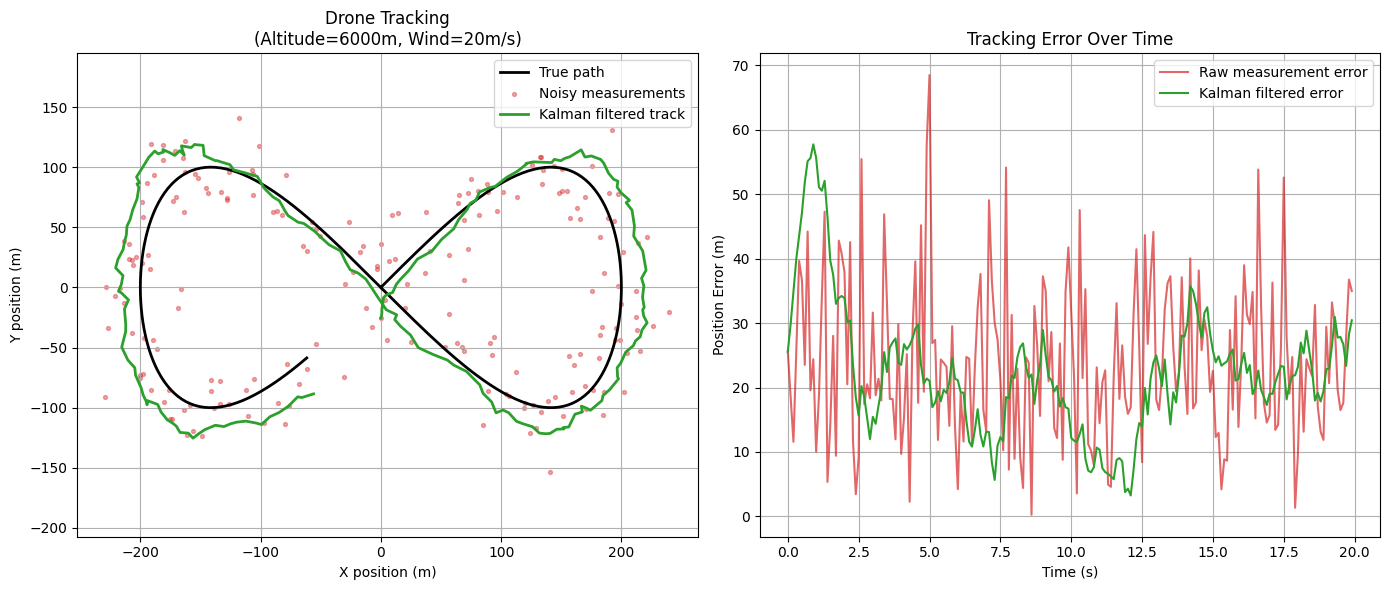


Day 4 complete. File saved: kalman_tracking.png


In [7]:
"""
Day 4 - Drone Detection & Tracking (Kalman Filter) - v3 (RETUNED)
High Altitude Anti-Drone System Simulation (SIH Problem Statement 26050)

Tuning history (documented honestly for the project report):
- v1: flat Q=0.5 across all states -> filter overshot at turns (34.6m error, worse than raw 15.8m)
- v2: "properly scaled" Q_discrete_white_noise with var=4.0 -> even worse (77.7m),
      because var=4.0 assumes very gentle maneuvering, but this flight path turns
      sharply (up to ~35 m/s^2 at the figure-eight crossing), so the filter
      distrusted real motion and lagged/overshot even more
- v3 (this version): var raised to match the path's actual acceleration profile,
      which is the standard way to tune Q - based on how hard the tracked
      object actually maneuvers, not an arbitrary constant

Requires: pip install filterpy numpy matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise
from scipy.linalg import block_diag

T0 = 288.15
L = 0.0065

def isa_temperature(altitude_m):
    return T0 - L * altitude_m


# ---------------------------------------------------------
# 1. True Drone Flight Path
# ---------------------------------------------------------
def generate_drone_path(duration_s=20, dt=0.1):
    time = np.arange(0, duration_s, dt)
    x = 200 * np.sin(0.3 * time)
    y = 100 * np.sin(0.6 * time)
    return time, x, y


# ---------------------------------------------------------
# 2. Environment-Linked Sensor Noise
# ---------------------------------------------------------
def sensor_noise_std(altitude_m, wind_speed):
    temp_c = isa_temperature(altitude_m) - 273.15
    cold_factor = max(0, (0 - temp_c)) / 40.0
    wind_factor = wind_speed / 25.0
    severity = np.clip(cold_factor * 0.5 + wind_factor * 0.5, 0, 1)

    base_noise = 3.0
    max_extra_noise = 25.0
    return base_noise + severity * max_extra_noise


def add_noisy_measurements(x, y, altitude_m, wind_speed, seed=7):
    rng = np.random.default_rng(seed)
    noise_std = sensor_noise_std(altitude_m, wind_speed)
    noisy_x = x + rng.normal(0, noise_std, size=len(x))
    noisy_y = y + rng.normal(0, noise_std, size=len(y))
    return noisy_x, noisy_y, noise_std


# ---------------------------------------------------------
# 3. Kalman Filter Setup (constant velocity model, 2D) - RETUNED v3
# ---------------------------------------------------------
def build_kalman_filter(dt, measurement_noise_std, first_measurement):
    kf = KalmanFilter(dim_x=4, dim_z=2)

    kf.F = np.array([
        [1, dt, 0, 0],
        [0, 1,  0, 0],
        [0, 0,  1, dt],
        [0, 0,  0, 1]
    ])

    kf.H = np.array([
        [1, 0, 0, 0],
        [0, 0, 1, 0]
    ])

    kf.R = np.eye(2) * (measurement_noise_std ** 2)

    # var here represents expected acceleration variance (m/s^2)^2.
    # This flight path turns sharply (up to ~35 m/s^2 at the crossing),
    # so var is set high enough for the filter to trust real maneuvering
    # instead of smoothing it away into overshoot.
    q_axis = Q_discrete_white_noise(dim=2, dt=dt, var=800.0)
    kf.Q = block_diag(q_axis, q_axis)

    kf.x = np.array([first_measurement[0], 0., first_measurement[1], 0.])
    kf.P = np.eye(4) * 20.0

    return kf


def run_kalman_tracking(noisy_x, noisy_y, dt, measurement_noise_std):
    first_measurement = (noisy_x[0], noisy_y[0])
    kf = build_kalman_filter(dt, measurement_noise_std, first_measurement)
    filtered_x, filtered_y = [], []

    for zx, zy in zip(noisy_x, noisy_y):
        kf.predict()
        kf.update(np.array([zx, zy]))
        filtered_x.append(kf.x[0])
        filtered_y.append(kf.x[2])

    return np.array(filtered_x), np.array(filtered_y)


# ---------------------------------------------------------
# 4. Run, Compare & Plot
# ---------------------------------------------------------
def run_tracking_demo(altitude_m=4500, wind_speed=12, duration_s=20, dt=0.1):
    time, true_x, true_y = generate_drone_path(duration_s, dt)
    noisy_x, noisy_y, noise_std = add_noisy_measurements(true_x, true_y, altitude_m, wind_speed)
    filtered_x, filtered_y = run_kalman_tracking(noisy_x, noisy_y, dt, noise_std)

    raw_error = np.sqrt((noisy_x - true_x)**2 + (noisy_y - true_y)**2)
    filtered_error = np.sqrt((filtered_x - true_x)**2 + (filtered_y - true_y)**2)

    settle_idx = int(1.0 / dt)

    print(f"Scenario: altitude={altitude_m}m, wind={wind_speed}m/s, "
          f"sensor noise std={noise_std:.1f}m")
    print(f"(Metrics below exclude the first 1s settling period)\n")
    print(f"Raw noisy measurement - mean error: {np.mean(raw_error[settle_idx:]):.2f}m, "
          f"max error: {np.max(raw_error[settle_idx:]):.2f}m")
    print(f"Kalman filtered track - mean error: {np.mean(filtered_error[settle_idx:]):.2f}m, "
          f"max error: {np.max(filtered_error[settle_idx:]):.2f}m")

    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    axs[0].plot(true_x, true_y, label="True path", color="black", linewidth=2)
    axs[0].scatter(noisy_x, noisy_y, label="Noisy measurements", color="tab:red",
                   s=8, alpha=0.4)
    axs[0].plot(filtered_x, filtered_y, label="Kalman filtered track",
               color="tab:green", linewidth=2)
    axs[0].set_title(f"Drone Tracking\n(Altitude={altitude_m}m, Wind={wind_speed}m/s)")
    axs[0].set_xlabel("X position (m)")
    axs[0].set_ylabel("Y position (m)")
    axs[0].legend()
    axs[0].grid(True)
    axs[0].axis("equal")

    axs[1].plot(time, raw_error, label="Raw measurement error", color="tab:red", alpha=0.7)
    axs[1].plot(time, filtered_error, label="Kalman filtered error", color="tab:green")
    axs[1].set_title("Tracking Error Over Time")
    axs[1].set_xlabel("Time (s)")
    axs[1].set_ylabel("Position Error (m)")
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.savefig("kalman_tracking.png", dpi=150)
    plt.show()


# ---------------------------------------------------------
# 5. Run it
# ---------------------------------------------------------
if __name__ == "__main__":
    print("Running Day 4 simulation (v3): drone tracking with Kalman filter\n")
    run_tracking_demo(altitude_m=6000, wind_speed=20)
    print("\nDay 4 complete. File saved: kalman_tracking.png")
